#H1N1 Vaccine Prediction Project

##Industry Level Machine Learning Project

#STEP 1 — IMPORT LIBRARIES

In [3]:
# =====================================================
# IMPORTING REQUIRED LIBRARIES
# =====================================================

# Pandas library is used for:
# - Reading dataset
# - Data manipulation
# - Data cleaning
# - Data analysis
import pandas as pd

# NumPy library is used for:
# - Numerical operations
# - Mathematical calculations
# - Array handling
import numpy as np

# Matplotlib library is used for:
# - Data visualization
# - Creating graphs and charts
import matplotlib.pyplot as plt

# Seaborn library is used for:
# - Advanced visualization
# - Beautiful statistical graphs
import seaborn as sns

# Warnings library is used for:
# - Hiding unnecessary warning messages
import warnings
warnings.filterwarnings('ignore')

## STEP 2 — LOAD DATASET

In [4]:
# =====================================================
# LOADING DATASET
# =====================================================

# read_csv() function is used to load CSV file
# CSV = Comma Separated Values

# Replace the file path with your dataset location

df = pd.read_csv('/content/h1n1_vaccine_prediction_20k.csv')

# head() function displays first 5 rows
# Helps understand dataset structure
print(df.head())

   Unique_Id  H1N1_Worry  H1N1_Awareness  Antiviral_Medication  \
0      23448         3.0             1.0                   0.0   
1      15284         2.0             1.0                   0.0   
2       1201         2.0             1.0                   0.0   
3       5683         1.0             1.0                   0.0   
4      21608         2.0             1.0                   0.0   

   Contact_Avoidance  Bought_Face_Mask  Wash_Hands_Frequently  \
0                0.0               0.0                    1.0   
1                1.0               0.0                    1.0   
2                1.0               0.0                    0.0   
3                0.0               0.0                    1.0   
4                0.0               0.0                    1.0   

   Avoid_Large_Gatherings  Reduced_Outside_Home_Cont  Avoid_Touch_Face  ...  \
0                     0.0                        1.0               1.0  ...   
1                     0.0                        0.0  

## STEP 3 — UNDERSTAND DATASET

In [5]:
# =====================================================
# BASIC DATASET INFORMATION
# =====================================================

# shape gives:
# - Number of rows
# - Number of columns
print(df.shape)

# info() gives:
# - Column names
# - Data types
# - Missing values
print(df.info())

# columns gives all column names
print(df.columns)

# describe() gives:
# - Statistical summary
# - Mean
# - Median
# - Standard deviation
print(df.describe())

(20000, 34)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unique_Id                  20000 non-null  int64  
 1   H1N1_Worry                 19936 non-null  float64
 2   H1N1_Awareness             19909 non-null  float64
 3   Antiviral_Medication       19948 non-null  float64
 4   Contact_Avoidance          19851 non-null  float64
 5   Bought_Face_Mask           19987 non-null  float64
 6   Wash_Hands_Frequently      19968 non-null  float64
 7   Avoid_Large_Gatherings     19933 non-null  float64
 8   Reduced_Outside_Home_Cont  19939 non-null  float64
 9   Avoid_Touch_Face           19899 non-null  float64
 10  Dr_Recc_H1N1_Vacc          18401 non-null  float64
 11  Dr_Recc_Seasonal_Vacc      18401 non-null  float64
 12  Chronic_Medic_Condition    19290 non-null  float64
 13  Cont_Child_Undr_6_Mnths    19411 n

## IMPORTANT TERMS EXPLANATION

| Term            | Meaning                          |
| --------------- | -------------------------------- |
| Rows            | Records or observations          |
| Columns         | Features or variables            |
| Feature         | Input column used for prediction |
| Target Variable | Output column to predict         |
| Null Values     | Missing data                     |
| Dataset         | Collection of structured data    |



# STEP 4 — CHECK MISSING VALUES


In [6]:
# =====================================================
# CHECKING NULL VALUES
# =====================================================

# isnull() checks missing values
# sum() counts total missing values

print(df.isnull().sum())
print("Number of  null values=",df.isnull().sum().sum())
df.shape

Unique_Id                       0
H1N1_Worry                     64
H1N1_Awareness                 91
Antiviral_Medication           52
Contact_Avoidance             149
Bought_Face_Mask               13
Wash_Hands_Frequently          32
Avoid_Large_Gatherings         67
Reduced_Outside_Home_Cont      61
Avoid_Touch_Face              101
Dr_Recc_H1N1_Vacc            1599
Dr_Recc_Seasonal_Vacc        1599
Chronic_Medic_Condition       710
Cont_Child_Undr_6_Mnths       589
Is_Health_Worker              583
Has_Health_Insur             9274
Is_H1N1_Vacc_Effective        301
Is_H1N1_Risky                 282
Sick_From_H1N1_Vacc           296
Is_Seas_Vacc_Effective        345
Is_Seas_Risky                 380
Sick_From_Seas_Vacc           408
Age_Bracket                     0
Qualification                 934
Race                            0
Sex                             0
Income_Level                 2896
Marital_Status                916
Housing_Status               1335
Employment    

(20000, 34)

In [7]:
df

,Unique_Id,H1N1_Worry,H1N1_Awareness,Antiviral_Medication,Contact_Avoidance,Bought_Face_Mask,Wash_Hands_Frequently,Avoid_Large_Gatherings,Reduced_Outside_Home_Cont,Avoid_Touch_Face,...,Race,Sex,Income_Level,Marital_Status,Housing_Status,Employment,Census_Msa,No_Of_Adults,No_Of_Children,H1N1_Vaccine
0,23448,3.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,...,Black,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,"MSA, Not Principle City",0.0,0.0,0
1,15284,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Black,Female,"> $75,000",Married,Own,Employed,"MSA, Principle City",1.0,0.0,0
2,1201,2.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,White,Female,"<= $75,000, Above Poverty",Not Married,Own,Employed,Non-MSA,1.0,0.0,0
3,5683,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,Other or Multiple,Female,"<= $75,000, Above Poverty",Not Married,Own,Unemployed,"MSA, Principle City",0.0,0.0,0
4,21608,2.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,Other or Multiple,Male,"> $75,000",Not Married,Own,Not in Labor Force,"MSA, Principle City",0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,9981,3.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,White,Female,"> $75,000",Not Married,Rent,Not in Labor Force,"MSA, Not Principle City",0.0,2.0,0
19996,23299,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,White,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,"MSA, Not Principle City",2.0,0.0,0
19997,26562,2.0,2.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,...,White,Female,"<= $75,000, Above Poverty",NaN,Own,Employed,"MSA, Not Principle City",0.0,0.0,0
19998,21266,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,"MSA, Not Principle City",0.0,0.0,0


## WHY WE CHECK MISSING VALUES?

## Industry Reason

Real-world healthcare datasets often contain:

* Missing patient information

* Incomplete surveys

* Human data entry errors

## ML Problem

Machine Learning algorithms cannot properly work with missing values.

# STEP 5 — HANDLE MISSING VALUES

In [8]:
# =====================================================
# HANDLING MISSING VALUES
# =====================================================

# Selecting categorical columns
categorical_cols = df.select_dtypes(include='object').columns

# Selecting numerical columns
numerical_cols = df.select_dtypes(exclude='object').columns

# Filling categorical missing values using MODE
# Mode = Most frequent value
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Filling numerical missing values using MEDIAN
# Median is better for outliers
for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [9]:
df

,Unique_Id,H1N1_Worry,H1N1_Awareness,Antiviral_Medication,Contact_Avoidance,Bought_Face_Mask,Wash_Hands_Frequently,Avoid_Large_Gatherings,Reduced_Outside_Home_Cont,Avoid_Touch_Face,...,Race,Sex,Income_Level,Marital_Status,Housing_Status,Employment,Census_Msa,No_Of_Adults,No_Of_Children,H1N1_Vaccine
0,23448,3.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,...,Black,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,"MSA, Not Principle City",0.0,0.0,0
1,15284,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Black,Female,"> $75,000",Married,Own,Employed,"MSA, Principle City",1.0,0.0,0
2,1201,2.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,White,Female,"<= $75,000, Above Poverty",Not Married,Own,Employed,Non-MSA,1.0,0.0,0
3,5683,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,Other or Multiple,Female,"<= $75,000, Above Poverty",Not Married,Own,Unemployed,"MSA, Principle City",0.0,0.0,0
4,21608,2.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,Other or Multiple,Male,"> $75,000",Not Married,Own,Not in Labor Force,"MSA, Principle City",0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,9981,3.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,White,Female,"> $75,000",Not Married,Rent,Not in Labor Force,"MSA, Not Principle City",0.0,2.0,0
19996,23299,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,White,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,"MSA, Not Principle City",2.0,0.0,0
19997,26562,2.0,2.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,...,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",0.0,0.0,0
19998,21266,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,"MSA, Not Principle City",0.0,0.0,0


## IMPORTANT TERMS

| Term       | Meaning                |
| ---------- | ---------------------- |
| Mode       | Most repeated value    |
| Median     | Middle value           |
| Outlier    | Extreme abnormal value |
| Imputation | Filling missing values |

## STEP 6 — CHECK DUPLICATE RECORDS

In [10]:
# =====================================================
# CHECKING DUPLICATE VALUES
# =====================================================

# duplicated() checks duplicate rows
print(df.duplicated().sum())

4


## STEP 7 — REMOVE DUPLICATES

In [11]:
# =====================================================
# REMOVING DUPLICATES
# =====================================================

# drop_duplicates() removes duplicate rows
# inplace=True means changes are saved permanently

df.drop_duplicates(inplace=True)

In [12]:
print(df.duplicated().sum())

0


## STEP 8 — EXPLORATORY DATA ANALYSIS (EDA)

# WHAT IS EDA?

EDA = Exploratory Data Analysis

**Purpose:**

* Understand data

* Find patterns

* Detect outliers

* Detect relationships

* Generate business insights


# STEP 9 — TARGET VARIABLE ANALYSIS

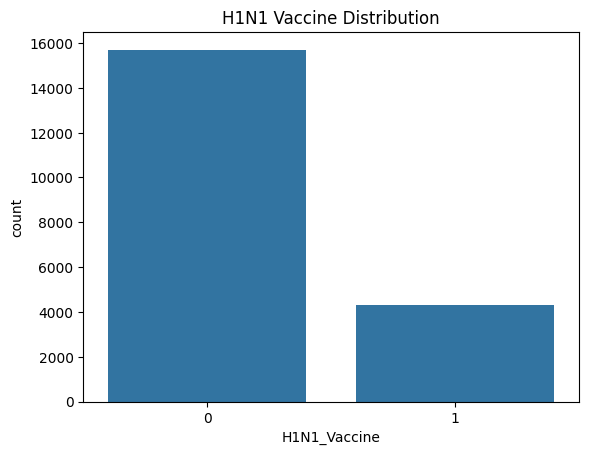

In [13]:
# =====================================================
# TARGET VARIABLE VISUALIZATION
# =====================================================

# countplot() creates frequency graph
# x parameter defines target column

sns.countplot(x='H1N1_Vaccine', data=df)

# title() adds graph title
plt.title('H1N1 Vaccine Distribution')

# show() displays graph
plt.show()

## WHY THIS GRAPH IS IMPORTANT?

## Business Use

Shows:

* How many people took vaccine
* How many people did not take vaccine

## ML Use

Checks class imbalance.


# IMPORTANT TERM

| Term            | Meaning                   |
| --------------- | ------------------------- |
| Class Imbalance | Unequal target categories |


## STEP 10 — CORRELATION HEATMAP

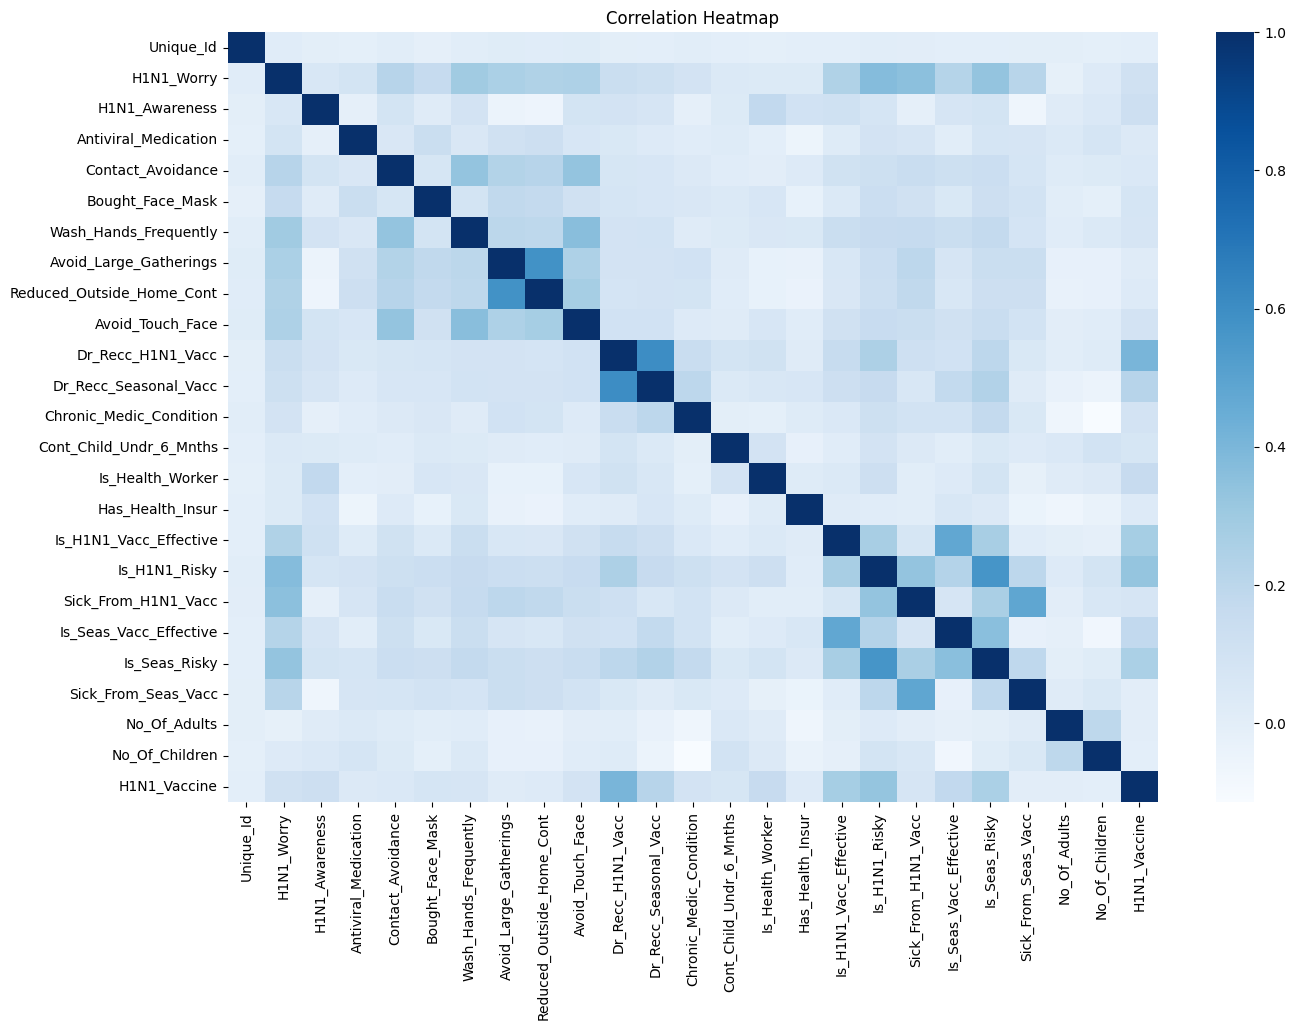

In [14]:
# =====================================================
# CORRELATION ANALYSIS
# =====================================================

# corr() calculates relationship between columns
correlation = df.corr(numeric_only=True)

# figure() sets graph size
plt.figure(figsize=(15,10))

# heatmap() creates correlation matrix
sns.heatmap(correlation, cmap='Blues')#coolwarm,Blues,Reds,Oranges,Purples,magma,Greens

plt.title('Correlation Heatmap')
plt.show()

## IMPORTANT TERMS

| Term                 | Meaning                             |
| -------------------- | ----------------------------------- |
| Correlation          | Relationship between variables      |
| Positive Correlation | Variables increase together         |
| Negative Correlation | One increases while other decreases |
| Heatmap              | Color-based data visualization      |

## STEP 11 — ENCODING CATEGORICAL DATA

# WHY ENCODING IS NEEDED?

Machine Learning models understand only numbers.

Example:

* Male → 0
* Female → 1

In [15]:
# =====================================================
# LABEL ENCODING
# =====================================================

# Import LabelEncoder
from sklearn.preprocessing import LabelEncoder

# Creating encoder object
le = LabelEncoder()

# Encoding categorical columns
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

## IMPORTANT TERMS

| Term            | Meaning                      |
| --------------- | ---------------------------- |
| Encoding        | Converting text into numbers |
| Label Encoding  | Assigning numeric labels     |
| fit_transform() | Learn + convert data         |


# STEP 12 — DEFINE FEATURES AND TARGET

In [16]:
# =====================================================
# DEFINING INPUT AND OUTPUT VARIABLES
# =====================================================

# X contains independent variables
# Features used for prediction
X = df.drop('H1N1_Vaccine', axis=1)

# y contains target variable
# Output column
y = df['H1N1_Vaccine']

## IMPORTANT TERMS

| Term                 | Meaning          |
| -------------------- | ---------------- |
| Independent Variable | Input features   |
| Dependent Variable   | Output feature   |
| axis=1               | Column operation |

## STEP 13 — TRAIN TEST SPLIT

In [17]:
# =====================================================
# SPLITTING DATA
# =====================================================

# train_test_split divides data into:
# - Training data
# - Testing data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# WHY TRAIN TEST SPLIT?

## Training Data

Used to train model.

## Testing Data

Used to check model performance on unseen data.

# IMPORTANT TERMS

| Term           | Meaning                              |
| -------------- | ------------------------------------ |
| test_size=0.2  | 20% data for testing                 |
| random_state   | Ensures same random split every time |
| Model Training | Learning patterns from data          |

## STEP 14 — FEATURE SCALING

# WHY SCALING IS NEEDED?

Some ML algorithms work better when all features are on same scale.

In [18]:
# =====================================================
# FEATURE SCALING
# =====================================================

from sklearn.preprocessing import StandardScaler

# Creating scaler object
scaler = StandardScaler()

# fit_transform() learns scaling from training data
X_train_scaled = scaler.fit_transform(X_train)

# transform() applies same scaling to testing data
X_test_scaled = scaler.transform(X_test)

# IMPORTANT TERMS

| Term           | Meaning                       |
| -------------- | ----------------------------- |
| Scaling        | Bringing values to same range |
| StandardScaler | Standardization technique     |
| fit()          | Learn data patterns           |
| transform()    | Apply learned transformation  |

# STEP 15 — MODEL BUILDING

# USING LOGISTIC REGRESSION

## WHY LOGISTIC REGRESSION?

Because:

* Best for classification problems
* Easy to interpret
* Industry standard baseline model


In [19]:
# =====================================================
# MODEL TRAINING
# =====================================================

# Importing Logistic Regression
from sklearn.linear_model import LogisticRegression

# Creating model object
model = LogisticRegression()

# fit() trains model using training data
model.fit(X_train_scaled, y_train)

LogisticRegression()

## IMPORTANT TERMS

| Term                | Meaning                         |
| ------------------- | ------------------------------- |
| Algorithm           | Mathematical learning method    |
| Model               | Trained machine learning system |
| fit()               | Training process                |
| Logistic Regression | Classification algorithm        |

## STEP 16 — MODEL PREDICTION

In [20]:
# =====================================================
# MAKING PREDICTIONS
# =====================================================

# predict() generates predictions
predictions = model.predict(X_test_scaled)

print(predictions)

[0 0 1 ... 0 0 0]


# IMPORTANT TERMS

| Term       | Meaning                         |
| ---------- | ------------------------------- |
| Prediction | Model output                    |
| Inference  | Using trained model on new data |

# STEP 17 — MODEL EVALUATION

In [21]:
# =====================================================
# MODEL PERFORMANCE CHECK
# =====================================================

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Accuracy calculation
accuracy = accuracy_score(y_test, predictions)

print('Accuracy:', accuracy)

# Confusion matrix
print(confusion_matrix(y_test, predictions))

# Classification report
print(classification_report(y_test, predictions))

Accuracy: 0.8305
[[2949  186]
 [ 492  373]]
              precision    recall  f1-score   support

           0       0.86      0.94      0.90      3135
           1       0.67      0.43      0.52       865

    accuracy                           0.83      4000
   macro avg       0.76      0.69      0.71      4000
weighted avg       0.82      0.83      0.82      4000



# IMPORTANT METRICS EXPLAINED

| Metric           | Meaning                              |
| ---------------- | ------------------------------------ |
| Accuracy         | Overall correct predictions          |
| Precision        | Correct positive predictions         |
| Recall           | Ability to detect positives          |
| F1 Score         | Balance between precision and recall |
| Confusion Matrix | Prediction comparison table          |

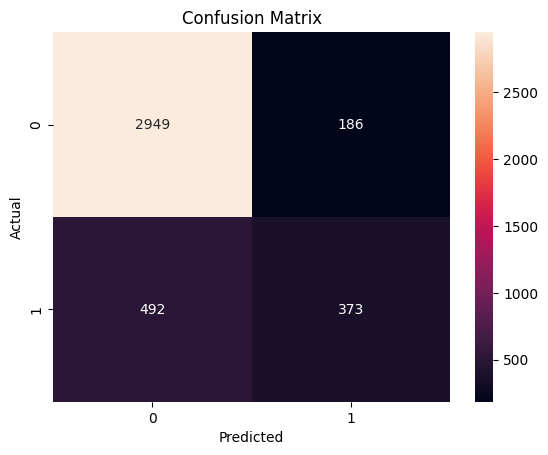

In [22]:
# STEP 18 — CONFUSION MATRIX VISUALIZATION
# =====================================================
# CONFUSION MATRIX HEATMAP
# =====================================================

cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt='d')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Our  model is slow  and  accuracy  is less  so  we use SMOTE Technique

In [23]:
# =========================================================
# Step 1 : Import Required Libraries
# =========================================================

from imblearn.over_sampling import SMOTE   # Use for balance the  data
from collections import Counter            # Check the count

# =========================================================
# Step 2 : Check Original Data Distribution
# =========================================================

print("Original Dataset Shape:")
print(Counter(y))

# Example Output:
# {0: 3135, 1: 865}

# =========================================================
# Step 3 : Apply SMOTE
# =========================================================

#
smote = SMOTE(random_state=42)

# fit_resample() :
#
X_balanced, y_balanced = smote.fit_resample(X, y)

# =========================================================
# Step 4 : Check Balanced Data
# =========================================================

print("Balanced Dataset Shape:")
print(Counter(y_balanced))

# Example Output:
# {0: 3135, 1: 3135}

Original Dataset Shape:
Counter({0: 15708, 1: 4288})
Balanced Dataset Shape:
Counter({0: 15708, 1: 15708})


# Now again we train the data,test data and  apply model  and check  this.

In [24]:
# =========================================================
# STEP 1 : Train Test Split
# =========================================================

from sklearn.model_selection import train_test_split

# Balanced data ko split karna

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced,
    y_balanced,
    test_size=0.2,
    random_state=42
)

# =========================================================
# STEP 2 : Import Model
# =========================================================

from sklearn.ensemble import RandomForestClassifier

# =========================================================
# STEP 3 : Create Model
# =========================================================

model = RandomForestClassifier()

# =========================================================
# STEP 4 : Train Model
# =========================================================

# fit() model ko training deta hai

model.fit(X_train, y_train)

# =========================================================
# STEP 5 : Prediction
# =========================================================

y_pred = model.predict(X_test)

# =========================================================
# STEP 6 : Evaluation
# =========================================================

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.9328453214513049


In [25]:
# Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94      3149
           1       0.96      0.90      0.93      3135

    accuracy                           0.93      6284
   macro avg       0.93      0.93      0.93      6284
weighted avg       0.93      0.93      0.93      6284



## STEP 19 — FEATURE IMPORTANCE

In [26]:
# =====================================================
# FEATURE IMPORTANCE ANALYSIS
# =====================================================

# Coefficients show feature impact
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

# Sorting important features
importance = importance.sort_values(by='Importance', ascending=False)

print(importance.head(10))

                   Feature  Importance
10       Dr_Recc_H1N1_Vacc    0.161786
17           Is_H1N1_Risky    0.104335
16  Is_H1N1_Vacc_Effective    0.101235
11   Dr_Recc_Seasonal_Vacc    0.066841
20           Is_Seas_Risky    0.053630
0                Unique_Id    0.046858
2           H1N1_Awareness    0.046607
19  Is_Seas_Vacc_Effective    0.036094
1               H1N1_Worry    0.029487
14        Is_Health_Worker    0.025593


# WHY FEATURE IMPORTANCE?

## Business Purpose

Helps identify:

* Most influential features
* Human behavior patterns
* Healthcare decision factors

In [27]:
# STEP 20 — SAVE MODEL
# =====================================================
# SAVING TRAINED MODEL
# =====================================================

# joblib library saves ML models
import joblib

# dump() saves trained model file
joblib.dump(model, 'h1n1_model.pkl')

print('Model Saved Successfully')

Model Saved Successfully


# IMPORTANT TERMS

| Term          | Meaning                         |
| ------------- | ------------------------------- |
| .pkl File     | Serialized model file           |
| Serialization | Saving object permanently       |
| Deployment    | Using model in real application |

In [28]:
# STEP 21 — LOAD SAVED MODEL
# =====================================================
# LOADING SAVED MODEL
# =====================================================

# load() loads saved model
loaded_model = joblib.load('h1n1_model.pkl')

## STEP 22 — REAL-TIME PREDICTION

In [29]:

# =====================================================
# REAL-TIME PREDICTION
# =====================================================

# Taking first row sample
sample = X_test_scaled[0].reshape(1, -1)

# Predicting vaccine decision
prediction = loaded_model.predict(sample)

print(prediction)

[0]


# INDUSTRY LEVEL PROJECT FLOW


1. Problem Understanding
2. Data Collection
3. Data Cleaning
4. Missing Value Handling
5. Exploratory Data Analysis
6. Feature Engineering
7. Encoding
8. Scaling
9. Train-Test Split
10. Model Training
11. Model Evaluation
12. Model Saving
13. Deployment

# INDUSTRY LEVEL INSIGHTS

## Business Insights

### 1. Doctor Recommendation

Most powerful factor influencing vaccination.

### 2. Awareness Level

Higher awareness increases vaccination probability.

### 3. Risk Perception

People who fear disease more are more likely to vaccinate.

### 4. Healthcare Workers

Healthcare workers usually have higher vaccine acceptance.

# IMPORTANT MACHINE LEARNING TERMS

| Term                | Meaning                            |
| ------------------- | ---------------------------------- |
| AI                  | Artificial Intelligence            |
| ML                  | Machine Learning                   |
| Supervised Learning | Learning using labeled data        |
| Classification      | Predicting categories              |
| Feature Engineering | Creating better input features     |
| Hyperparameter      | Algorithm configuration            |
| Overfitting         | Model memorizes training data      |
| Underfitting        | Model fails to learn patterns      |
| Generalization      | Model performs well on unseen data |

## FINAL CONCLUSION

This project is an industry-level healthcare machine learning project because it includes:

* Real-world healthcare data
* Data preprocessing
* Missing value handling
* Exploratory data analysis
* Feature engineering
* Classification algorithms
* Model evaluation
* Business insights
* Model deployment concepts